In [1]:
import numpy as np
import cv2
import json
import os
import matplotlib.pyplot as plt
import torch
import sys

sys.path.append("..")
from segment_anything import sam_model_registry, SamPredictor

sam_checkpoint = "/kaggle/input/models/metaresearch/segment-anything/pytorch/vit-l/1/model.pth"
model_type = "vit_l"
device = "cuda"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

In [2]:

IMAGE_FOLDER  = "/kaggle/input/datasets/paultimothymooney/kermany2018/OCT2017 /test/NORMAL/"   
OUTPUT_FOLDER = "/kaggle/working/binary_masks"    
# ────────────────────────────────────────────────────────────────────────

with open("/kaggle/input/datasets/andreherrerauwat/annotations-test/annotations.json") as f:
    ANNOTATIONS = json.load(f)

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

In [3]:
def generate_binary_mask(image_rgb, points_data):
    predictor.set_image(image_rgb)

    coords = np.array([[p["x"], p["y"]] for p in points_data])
    labels = np.array([p["label"]        for p in points_data])

    masks, scores, _ = predictor.predict(
        point_coords=coords,
        point_labels=labels,
        multimask_output=True,
    )

    best_idx   = int(np.argmax(scores))
    best_mask  = masks[best_idx]                          # bool HxW

    binary_mask = (best_mask * 255).astype(np.uint8)
    return binary_mask, scores[best_idx]

In [4]:
def generate_binary_mask(image_rgb, points_data):
    predictor.set_image(image_rgb)

    coords = np.array([[p["x"], p["y"]] for p in points_data])
    labels = np.array([p["label"]        for p in points_data])

    masks, scores, _ = predictor.predict(
        point_coords=coords,
        point_labels=labels,
        multimask_output=True,
    )

    best_idx   = int(np.argmax(scores))
    best_mask  = masks[best_idx]                          # bool HxW

    binary_mask = (best_mask * 255).astype(np.uint8)
    return binary_mask, scores[best_idx]

In [5]:
for filename, meta in ANNOTATIONS.items():
    image_path = os.path.join(IMAGE_FOLDER, filename)

    if not os.path.exists(image_path):
        print(f"[SKIP] No encontrada: {filename}")
        continue

    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    binary_mask, score = generate_binary_mask(image_rgb, meta["points"])

    stem        = os.path.splitext(filename)[0]
    output_path = os.path.join(OUTPUT_FOLDER, f"{stem}_mask.png")
    cv2.imwrite(output_path, binary_mask)

    print(f"[OK] {filename}  →  score={score:.3f}  →  {output_path}")



[OK] NORMAL-12494-3.jpeg  →  score=0.989  →  /kaggle/working/binary_masks/NORMAL-12494-3_mask.png
[OK] NORMAL-307151-2.jpeg  →  score=0.981  →  /kaggle/working/binary_masks/NORMAL-307151-2_mask.png
[OK] NORMAL-402066-3.jpeg  →  score=1.000  →  /kaggle/working/binary_masks/NORMAL-402066-3_mask.png
[OK] NORMAL-447690-1.jpeg  →  score=0.998  →  /kaggle/working/binary_masks/NORMAL-447690-1_mask.png
[OK] NORMAL-469935-1.jpeg  →  score=0.990  →  /kaggle/working/binary_masks/NORMAL-469935-1_mask.png
[OK] NORMAL-524640-1.jpeg  →  score=1.002  →  /kaggle/working/binary_masks/NORMAL-524640-1_mask.png
[OK] NORMAL-544711-1.jpeg  →  score=0.989  →  /kaggle/working/binary_masks/NORMAL-544711-1_mask.png
[OK] NORMAL-557437-1.jpeg  →  score=0.992  →  /kaggle/working/binary_masks/NORMAL-557437-1_mask.png
[OK] NORMAL-571157-1.jpeg  →  score=0.998  →  /kaggle/working/binary_masks/NORMAL-571157-1_mask.png
[OK] NORMAL-651257-1.jpeg  →  score=0.977  →  /kaggle/working/binary_masks/NORMAL-651257-1_mask.png
[O

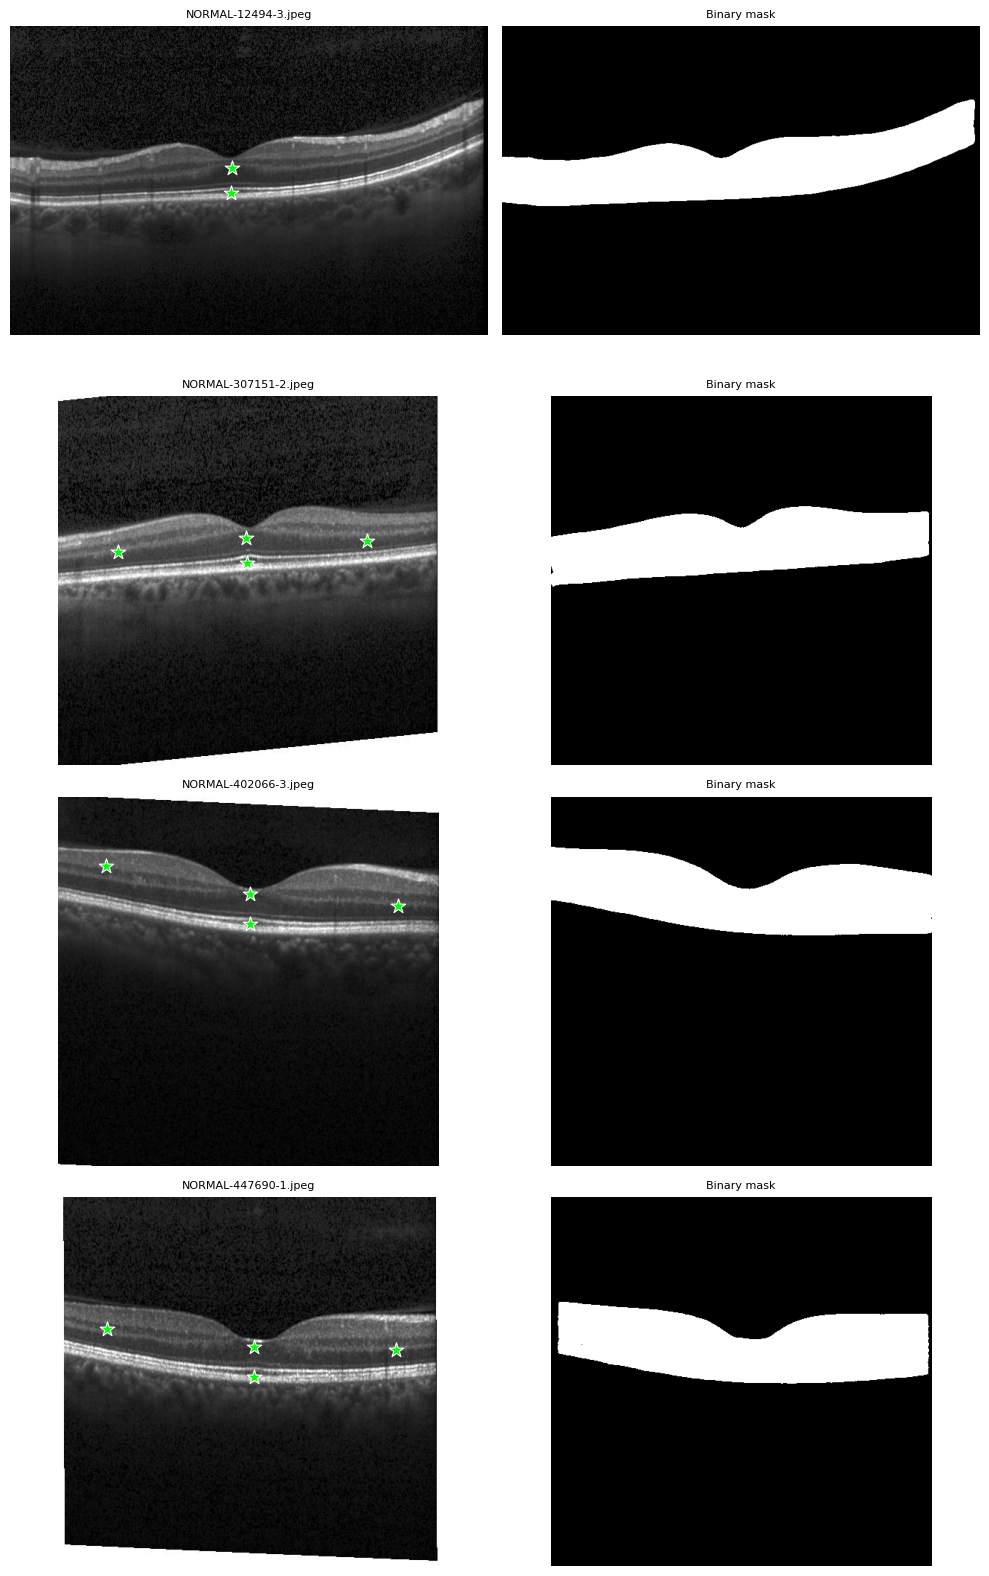

In [6]:
N = 4 

samples = list(ANNOTATIONS.keys())[:N]

fig, axes = plt.subplots(N, 2, figsize=(10, 4 * N))

for i, filename in enumerate(samples):
    stem        = os.path.splitext(filename)[0]
    image_path  = os.path.join(IMAGE_FOLDER, filename)
    mask_path   = os.path.join(OUTPUT_FOLDER, f"{stem}_mask.png")

    image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Imagen con puntos
    ax_img = axes[i, 0]
    ax_img.imshow(image)
    for p in ANNOTATIONS[filename]["points"]:
        color = "lime" if p["label"] == 1 else "red"
        ax_img.scatter(p["x"], p["y"], c=color, s=120, marker="*",
                       edgecolors="white", linewidths=0.8)
    ax_img.set_title(filename, fontsize=8)
    ax_img.axis("off")

    # Máscara binaria
    ax_msk = axes[i, 1]
    ax_msk.imshow(mask, cmap="gray")
    ax_msk.set_title("Binary mask", fontsize=8)
    ax_msk.axis("off")

plt.tight_layout()
plt.show()